In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

class GreetState(BaseModel):
    message: str = ""

In [20]:
graph = StateGraph(GreetState)


In [18]:
def greet(state:GreetState):
    state.message = f"{state.message} , All Good !!"
    return state


def upperCase(state:GreetState):
    state.message = state.message.upper()
    return state

def lowerCase(state:GreetState):
    state.message = state.message.lower()
    return state

In [21]:
graph.add_node("greet",greet)

In [22]:
graph.add_node("upper_case",upperCase)

In [23]:
graph.add_node("lower_case",lowerCase)

In [48]:
from random import random

def decideNextStep(state):
    num = (random() * 10).__ceil__()

    if(num % 2 == 0):
        return "upper_case"
    else:
        return "lower_case"

In [49]:
graph.add_edge(START,"greet")
graph.add_conditional_edges("greet",decideNextStep , {"upper_case":'upper_case',"lower_case":"lower_case"})
graph.add_edge("upper_case",END)
graph.add_edge("lower_case",END)

In [50]:
final_graph = graph.compile()

In [57]:
response = final_graph.invoke({"message":"I love AI and ML"})

In [58]:
response

{'message': 'i love ai and ml , all good !!'}

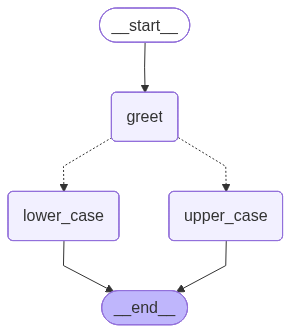

In [59]:
from IPython.display import Image
Image(final_graph.get_graph().draw_mermaid_png())